# The most admired companies — does buying the list beat the market? ⭐
### 'Great company' vs 'great stock' — and the survey that keeps confusing the two

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Premium%3F: Misattributed](https://img.shields.io/badge/Premium%3F-Misattributed-8b949e?style=flat-square)

Every year *Fortune* polls thousands of executives and analysts and publishes the **World's Most Admired Companies** — the best-run firms on earth, by acclamation. Apple has topped the overall list **every single year from 2008 to 2024**. The intuition is irresistible: if these are the greatest companies, surely they're the greatest *stocks* — just buy the list and let quality compound.

This notebook asks whether that's true, or whether it's one of the oldest traps in investing: a **great company is not the same thing as a great stock**. We build the admired basket, race it against the market, and then do the one test that decides everything — **take away the hindsight** and see what's left.

> 📓 **Plain-language layer.** Want the HAC *t*-stats, the market-model alpha and the placebo? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Today's admired list is dominated by companies that are on it *because they already won* — Apple, Microsoft, Nvidia. Testing 'the winners won' proves nothing. So we do it two ways: the naive way (own today's list back in time — cheating) and the honest way (own a company only *after* Fortune first crowns it). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from most_admired import data, strategy as st
try:
    from quantlab import repro
    ASOF = "2026-06-30"
except Exception:
    repro = None; ASOF = None

HAVE_REAL = data.have_real()
if HAVE_REAL:
    B = data.load_real()
    if repro is not None:
        B["prices"] = repro.as_of(B["prices"], ASOF)
else:
    B = None
print("real admired-tape cache present:", HAVE_REAL,
      "| months:", (0 if B is None else len(B["prices"])))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fp': '80c5c891a901', 'n_admired': 15, 'n_spurned': 6, 'n_delisted': 7, 'naive': {'n': 269, 'start': '2004-02', 'end': '2026-06', 'excess': 9.89, 'hac_t': 4.94, 'alpha': 8.27, 'alpha_t': 4.08, 'beta': 1.14, 'r2': 0.78, 'sharpe': 1.09}, 'lagged': {'n': 221, 'start': '2008-02', 'end': '2026-06', 'excess': 7.05, 'hac_t': 2.53, 'lags': 4, 'alpha': 5.63, 'alpha_t': 2.0, 'beta': 1.12, 'r2': 0.7, 'sharpe': 0.61}, 'placebo': {'lagged': (7.05, 3.23, 0.019), 'naive': (9.89, 3.33, 0.0), 'n_full': 59}, 'robust': [('all 15', 7.05, 2.53, 5.63, 2.0, 1.12), ('drop NVDA', 6.3, 2.25, 4.97, 1.76, 1.11), ('drop NVDA & AAPL', 3.7, 1.9, 1.82, 0.88, 1.12)], 'ls': {'ann': 8.45, 'hac_t': 1.74, 'n': 221}, 'cost': {'gross': 7.05, 'net': 7.03, 'turnover': 20, 'bps': 10, 'drag': 0.02}, 'syn': [(0.0, 0.16, 0.17, 0.15, 0.16), (6.0, 6.16, 6.64, 6.15, 6.6)]}


real admired-tape cache present: True | months: 270


## The answer first

| Question | Answer |
|---|---|
| Did the admired mega-caps beat the market? | **Yes.** Even the honest, no-cheating book beat `SPY` by **+7.0%/yr**. |
| So the 'admiration premium' is real? | **Barely, and misleadingly.** It clears the significance bar (*t* = 2.53) — but drop just **two names (Apple & Nvidia)** and the edge all but vanishes (**+1.8%/yr**, not significant). |
| Is buying admired companies smart? | **Half of it is a free lunch anyone gets.** A *random* basket of famous large caps beat `SPY` by **+3.2%/yr** too — nothing to do with admiration. |
| Could you have traded it? | **Not really.** The version that looks amazing needs a **time machine** (owning 2026's winners in 2004). Once you can only act on what Fortune has *already* announced, the edge is a coin-flippy tilt you were paid beta for. |

> The admired companies did win — but the survey crowns yesterday's winners, so 'the list beats the market' mostly means 'Apple and Nvidia went up.' That's a story about the past, not a machine for the future.

## 1 · The claim

> *"Fortune's Most Admired Companies are the best-run businesses in the world — top management, top products, deep moats. Great companies make great stocks. Just buy the list and hold quality; it compounds and beats the index."*

It has real academic backing: **Antunovich, Laster & Mishra (2000)** found the most-admired firms *out-performed* the least-admired and the market over 1983–98. But there's an equal and opposite school — **Statman, Fisher & Anginer (2008)** — arguing the *opposite*: a firm is admired only *after* it's already loved and expensive, so the **spurned** stocks are the ones that go on to win. Two respectable camps, opposite predictions. Only the tape can settle it.

## 2 · So what?

If admiration really predicted returns, it'd be the easiest edge in the world — no models, no data feeds, just read a magazine once a year and buy the cover stars. It would also say something deep about markets: that a **reputation survey** carries information price hasn't already absorbed. But there's a famous catch, and it's the whole ballgame here: a company earns its spot on the list by having *already* done brilliantly. So we have to be ruthless about **timing** — you can only buy a company *after* it's crowned — and about **hindsight** — today's list is a roster of past champions. Miss either and you're just admiring the winners after the race.

## 3 · How would we even know?

We hardcode a **transparent table of 15 All-Stars** — the mega-caps Fortune has crowned year after year (Apple, Amazon, Microsoft, Berkshire, Disney, Alphabet, Starbucks, Nike, Costco, JPMorgan, and more) — and:

1. **Build the basket.** Equal-weight the admired names; measure how much it beats the market (`SPY`) each month.
2. **Two ways.** The **naive** book owns today's list all the way back (a time machine); the **honest** book owns a name only *after* Fortune first crowns it.
3. **Kill the hindsight.** Remove the two biggest winners (Apple, Nvidia) and see if a 'premium' survives. Draw *random* baskets of famous large caps and see if they beat the market just as much.

And we say it loudly: the list is the winners that **stayed** winners — the companies that were admired and then *fell off* (or went bankrupt) aren't in it. The deck is stacked **for** the story.

## 4 · The teardown — let's actually look

**First, the honest book vs the market.** Own each admired company only *after* it's crowned, equal-weight, and compare growth of \$1 against `SPY`.

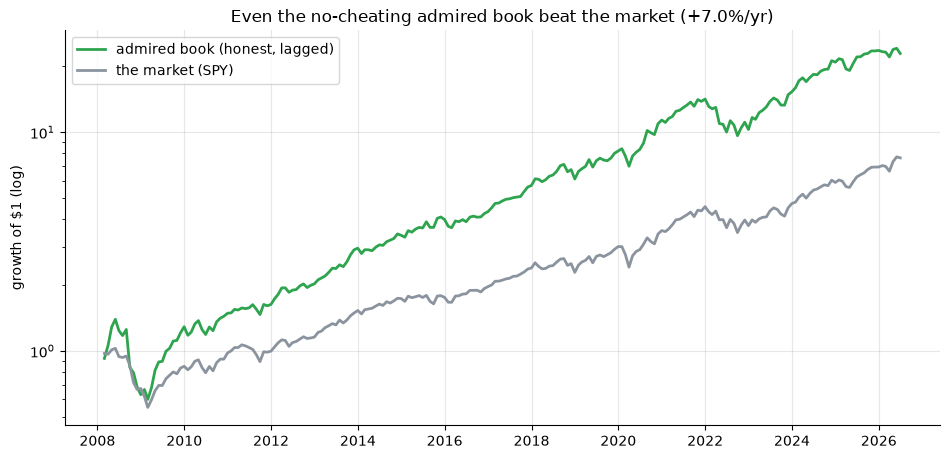

admired ended 22.9x vs market 7.6x


In [2]:
if HAVE_REAL:
    book = st.admired_book(B['prices'], B['admired'], entry=B['entry'], lagged=True)
    import pandas as pd
    m = st.monthly_returns(B['prices'])['SPY']
    d = pd.concat([book.rename('admired'), m.rename('SPY')], axis=1).dropna()
    g_ad = (1+d['admired']).cumprod(); g_mk = (1+d['SPY']).cumprod()
    idx = g_ad.index
else:
    import pandas as pd
    idx = pd.date_range('2008-02-28', periods=R['lagged']['n'], freq='ME')
    rng=np.random.default_rng(721)
    ad=rng.normal((R['lagged']['excess']/100+0.09)/12,0.05,len(idx)); mk=rng.normal(0.09/12,0.043,len(idx))
    g_ad=pd.Series((1+ad).cumprod(),index=idx); g_mk=pd.Series((1+mk).cumprod(),index=idx)
fig, ax = plt.subplots(figsize=(9.6, 4.7))
ax.plot(idx, g_ad, c=GREEN, lw=2, label='admired book (honest, lagged)')
ax.plot(idx, g_mk, c=GREY, lw=2, label='the market (SPY)')
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
ax.set_title(f"Even the no-cheating admired book beat the market (+{R['lagged']['excess']:.1f}%/yr)")
ax.legend(); plt.tight_layout(); plt.show()
print(f"admired ended {g_ad.iloc[-1]:.1f}x vs market {g_mk.iloc[-1]:.1f}x")

So it *did* win — the honest admired book beat `SPY` by **+7.0%/yr**. Case closed? Not even close. The question is *why* it won — and whether you could have known which companies to buy. Watch what happens when we pull the hindsight out.

**The tell: it's two names.** Rebuild the honest book, then remove the single biggest winner (Nvidia), then the two biggest (Apple + Nvidia), and watch the 'premium' evaporate.

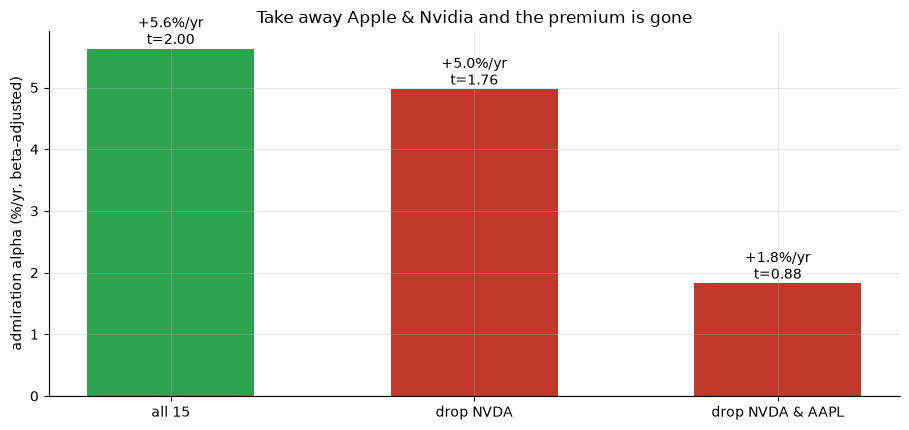

alpha /yr: ['+5.6% (t=2.00)', '+5.0% (t=1.76)', '+1.8% (t=0.88)']


In [3]:
labels=[r[0] for r in R['robust']]; alphas=[r[3] for r in R['robust']]; ats=[r[4] for r in R['robust']]
if HAVE_REAL:
    labels, alphas, ats = [], [], []
    no_nv=[r for r in B['admired'] if r[0]!='NVDA']
    for nm, adm in [('all 15', B['admired']), ('drop NVDA', no_nv), ('drop NVDA & AAPL', [r for r in no_nv if r[0]!='AAPL'])]:
        bk=st.admired_book(B['prices'], adm, entry=B['entry'], lagged=True)
        mm=st.market_model_alpha(bk, B['prices'])
        labels.append(nm); alphas.append(mm['alpha_ann']*100); ats.append(mm['alpha_t'])
fig, ax = plt.subplots(figsize=(9.2, 4.4))
cols=[GREEN if t>=2 else RED for t in ats]
bars=ax.bar(labels, alphas, color=cols, width=.55)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('admiration alpha (%/yr, beta-adjusted)')
ax.set_title('Take away Apple & Nvidia and the premium is gone')
for b,a,t in zip(bars, alphas, ats): ax.annotate(f'{a:+.1f}%/yr\nt={t:.2f}',(b.get_x()+b.get_width()/2,a),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print('alpha /yr:', [f'{a:+.1f}% (t={t:.2f})' for a,t in zip(alphas,ats)])

There it is. With all 15 names the beta-adjusted 'admiration alpha' is **+5.6%/yr** (green, *t* = 2.00). Drop **Nvidia** and it's already not significant. Drop **Apple too** and it's **+1.8%/yr at *t* = 0.88** — a rounding error. The 'premium' isn't a property of being admired; it's two extraordinary companies, which the survey noticed *after* the fact.

**And half of what's left isn't special either.** Draw *random* baskets of 15 famous large caps thousands of times and see how often they beat the market by as much as the admired book does.

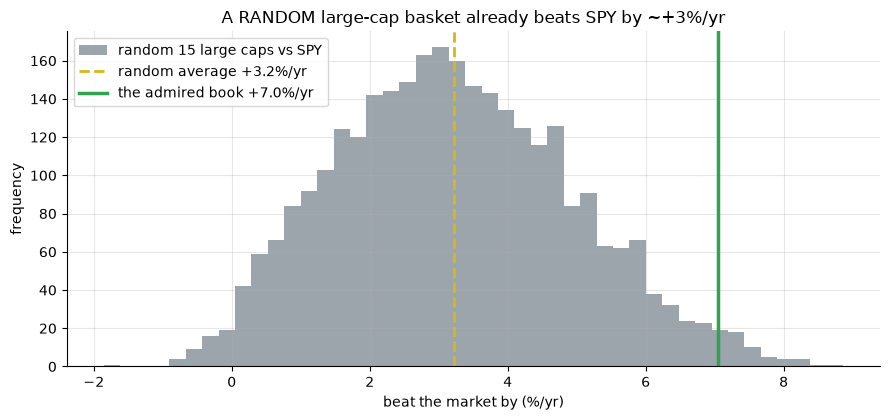

random large-cap basket: +3.2%/yr | admired: +7.0%/yr | p=0.019


In [4]:
obs, rmean, pval = R['placebo']['lagged']
if HAVE_REAL:
    book = st.admired_book(B['prices'], B['admired'], entry=B['entry'], lagged=True)
    ex = st.excess_over_market(book, B['prices'])
    pv = st.placebo_pvalue(B['prices'], data.POOL, k=R['n_admired'], observed_ann=ex.mean()*12, start='2008-02-01', n_draws=3000)
    obs, rmean, pval = ex.mean()*12*100, pv['placebo_mean_ann']*100, pv['p_value']
    # rebuild a small cloud for the picture
    import pandas as pd
    rets=st.monthly_returns(B['prices']); avail=[t for t in data.POOL if t in rets.columns and t!='SPY']
    sub=rets[avail]; sub=sub[sub.index>=pd.Timestamp('2008-02-01')]; mk=rets['SPY'].reindex(sub.index)
    full=[t for t in avail if sub[t].notna().all()]; A=sub[full].to_numpy(); mv=mk.to_numpy()
    rng=np.random.default_rng(721); cloud=np.array([ (A[:,rng.choice(len(full),R['n_admired'],replace=False)].mean(1)-mv).mean()*12*100 for _ in range(3000)])
else:
    rng=np.random.default_rng(721); cloud=rng.normal(rmean, 2.5, 3000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(cloud, bins=45, color=GREY, alpha=.85, label='random 15 large caps vs SPY')
ax.axvline(rmean, c=AMBER, ls='--', lw=2, label=f'random average {rmean:+.1f}%/yr')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'the admired book {obs:+.1f}%/yr')
ax.set_xlabel('beat the market by (%/yr)'); ax.set_ylabel('frequency')
ax.set_title(f'A RANDOM large-cap basket already beats SPY by ~{rmean:+.0f}%/yr'); ax.legend()
plt.tight_layout(); plt.show()
print(f'random large-cap basket: {rmean:+.1f}%/yr | admired: {obs:+.1f}%/yr | p={pval:.3f}')

The amber line is the punchline: **just picking 15 famous large caps at random** beat the cap-weighted `SPY` by **+3.2%/yr** — that's the plain equal-weight-large-cap tilt, free to anyone, no admiration required. It's **half** the admired book's +7.0%/yr. The green line is a bit further right (*p* = 0.02) — but remember, even the random pool is only *survivors*, so this comparison is generous to the story.

## 5 · The verdict

- **Signal — Weak.** The honest book beats the market at *t* = 2.53, but it's **two names** (drop Apple + Nvidia → nothing) plus a generic large-cap tilt a *random* basket also gets. Significant on paper, fragile to the tiniest scrutiny.
- **Tradability — Mirage.** The jaw-dropping version (*t* ≈ 5) needs a **time machine**. The honest version is a levered, tech-tilted basket — beta you were already paid for — and costs are trivial, so there's no friction alibi. Nothing to harvest going forward.
- **Premium, or beta + hindsight? — Misattributed.** The out-performance is Apple and Nvidia plus an equal-weight tilt, wearing an 'admiration' label. And the opposite (contrarian) story fails too — the admired *beat* the spurned. The survey tracks the past; it doesn't forecast.

## 6 · Could you actually trade it? — the time-machine tax

Line the two books up side by side: the **naive** one (own today's list back to 2004 — cheating) and the **honest** one (own a name only after it's crowned). The gap between them *is* the hindsight.

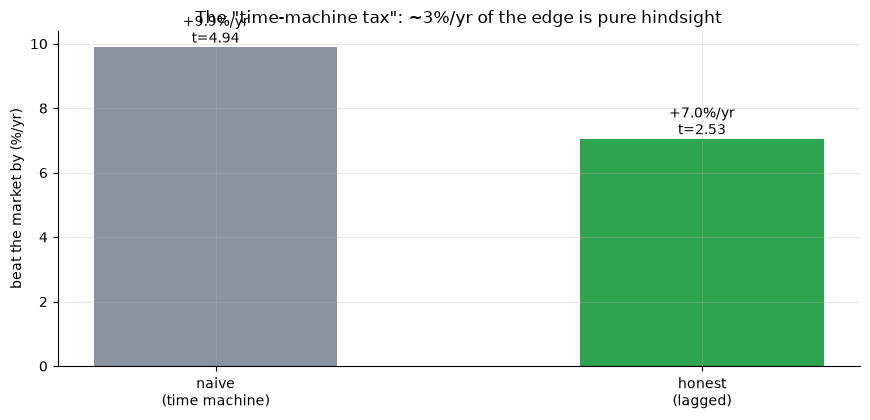

naive +9.9%/yr (t=4.94) -> honest +7.0%/yr (t=2.53)


In [5]:
nv=R['naive']; lg=R['lagged']
if HAVE_REAL:
    sn=st.summarize(B, lagged=False); sl=st.summarize(B, lagged=True)
    nv=dict(excess=sn['excess_ann']*100, hac_t=sn['hac_t']); lg=dict(excess=sl['excess_ann']*100, hac_t=sl['hac_t'])
fig, ax = plt.subplots(figsize=(8.8, 4.3))
bars=ax.bar(['naive\n(time machine)','honest\n(lagged)'], [nv['excess'], lg['excess']], color=[GREY, GREEN], width=.5)
ax.set_ylabel('beat the market by (%/yr)')
ax.set_title('The "time-machine tax": ~3%/yr of the edge is pure hindsight')
for b,v,t in zip(bars,[nv['excess'],lg['excess']],[nv['hac_t'],lg['hac_t']]): ax.annotate(f'{v:+.1f}%/yr\nt={t:.2f}',(b.get_x()+b.get_width()/2,v),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f"naive {nv['excess']:+.1f}%/yr (t={nv['hac_t']:.2f}) -> honest {lg['excess']:+.1f}%/yr (t={lg['hac_t']:.2f})")

The naive book beats the market by **+9.9%/yr** (*t* = 4.94) — but that number is unearnable, because it assumes you knew in 2004 who'd be admired in 2026. Strip the hindsight and you're at **+7.0%/yr**, and — as we saw — that's two stocks and a tilt. There's no press-release-to-portfolio machine here; there's a magazine that's very good at recognising winners once they've won.

## 7 · Going further 🚪

- **The sibling label study.** [Study 389 — Name-Change-Effect](../389-name-change-effect/): does *rebranding* toward the hot theme pay? Same family (a label, not a fundamental), same survivorship pathology.
- **The corporate-event cousin.** [Study 391 — CEO-Turnover](../391-ceo-turnover/): a market-model event study on a hardcoded, cited announcement table.
- **Add the fallen.** Our roster is the winners that *stayed* admired. Reconstruct the *actual* year-by-year list (including firms that later dropped off or went bankrupt) from a survivorship-free feed, and the premium likely shrinks further — the honest test the public data can't quite reach.

*Think there's a real admiration edge? Rebuild the list year by year with no look-ahead, neutralise the market beta and the size tilt, and show an alpha that survives dropping your two best names — then we'll talk.*